# Exploratory Data Analysis of Top 30 Sensex Companies

### Historical Stock Market Analysis (Last 3 Years)

**Tools Used**

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Streamlit (Dashboard Development)

---

# Introduction

The stock market generates a large amount of financial data every trading day. Analyzing this data helps understand historical price movements, trading activity, and overall market behavior.

This project performs an Exploratory Data Analysis (EDA) on the historical stock prices of the Top 30 companies listed in the S&P BSE Sensex Index. The dataset contains historical daily trading data, including Open, High, Low, Close, Adjusted Close, and Volume for each company.

The analysis focuses on understanding the dataset, assessing data quality, performing feature engineering, exploring stock price behavior, and identifying meaningful patterns through statistical analysis and visualization. The insights obtained from this analysis will serve as the foundation for developing an interactive Streamlit dashboard for stock exploration and comparison.

# Project Objectives

The primary objectives of this project are:

* Analyze the historical stock performance of the Top 30 companies listed in the S&P BSE Sensex Index.
* Understand the structure and quality of the dataset.
* Perform data cleaning and validation to ensure data consistency.
* Create additional features such as Daily Price Change and Daily Return for analysis.
* Explore the distribution of stock prices, trading volume, and daily returns.
* Analyze relationships between important financial variables.
* Study historical stock price movements using time-series analysis.
* Compare the historical performance of different companies using descriptive statistics and visualizations.
* Generate meaningful insights from historical stock market data.
* Build an interactive Streamlit dashboard for stock exploration and comparison.

# Dataset Description

The dataset contains daily historical stock market data for the top 30 companies of the S&P BSE Sensex Index over the last three years.

Each record represents one trading day for a particular company.

# Notebook Workflow & Features

This notebook follows the standard Exploratory Data Analysis workflow:

1. Dataset Overview

2. Data Cleaning & Quality Assessment

3. Feature Engineering
    * 3.1 Daily Return
    * 3.2 Daily Change
    * 3.3 20-Day Moving Average
    * 3.4 50-Day Moving Average

4. Univariate Analysis
    * 4.1 Closing Price Analysis
    * 4.2 Trading Volume Analysis
    * 4.3 Daily Return Analysis

5. Bivariate Analysis
    * 5.1 Open Price vs Closing Price
    * 5.2 Trading Volume vs Closing Price
    * 5.3 Average Closing Price by Company
    * 5.4 Average Trading Volume by Company
    * 5.5 Daily Return Distribution by Company

6. Multivariate Analysis
    * 6.1 Correlation Heatmap of closing prices

7. Time Series Analysis
    * 7.1 Closing Price Trend
    * 7.2 Trading Volume Trend
    * 7.3 Moving Average Analysis

8. Performance Analysis
    * 8.1 Average Daily Return by Company
    * 8.2 Total Reutrn by Company
    * 8.3 Volatility Comparison
    * 8.4 Top Performing Companies
    * 8.5 Bottom Performing Companies
    * 8.6 Highest Volatility Companies
    * 8.7 Lowest Volatility Companies

## 1. Dataset Overview

This section provides an overview of the dataset by examining its structure, dimensions, data types, and basic statistical properties. Understanding these characteristics helps establish a clear foundation before performing data cleaning and analysis.


In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [116]:
master_df = pd.read_csv("../data/Sensex29_Master_Cleaned.csv")

In [117]:
master_df["Date"] = pd.to_datetime(master_df["Date"])

In [118]:
master_df.shape

(21707, 7)

In [119]:
master_df.head()

,Stock,Date,Close,High,Low,Open,Volume
0,ADANIPORTS,2023-07-03,722.769226,732.619811,718.162467,729.728331,2808490.0
1,ADANIPORTS,2023-07-04,726.983948,736.099415,720.416870,725.366661,3263045.0
2,ADANIPORTS,2023-07-05,728.013062,732.080745,719.485667,726.297783,2212779.0
3,ADANIPORTS,2023-07-06,725.366638,731.100604,723.553368,727.670048,1949877.0
4,ADANIPORTS,2023-07-07,704.440369,725.317746,701.989971,725.268750,4248724.0


In [120]:
master_df.tail()

,Stock,Date,Close,High,Low,Open,Volume
21702,ULTRACEMCO,2026-06-26,11489.0,11489.0,11489.0,11489.0,0.0
21703,ULTRACEMCO,2026-06-29,11336.0,11539.0,11313.0,11457.0,230886.0
21704,ULTRACEMCO,2026-06-30,11253.0,11377.0,11219.0,11317.0,331714.0
21705,ULTRACEMCO,2026-07-01,11456.0,11485.0,11298.0,11300.0,119013.0
21706,ULTRACEMCO,2026-07-02,11530.0,11559.0,11443.0,11531.0,60667.0


In [121]:
master_df.sample(7)

,Stock,Date,Close,High,Low,Open,Volume
15188,RELIANCE,2024-10-31,1320.645020,1331.501217,1314.795511,1328.526903,9331650.0
12641,NESTLEIND,2023-07-17,1120.672974,1136.440559,1115.050384,1126.951379,835900.0
15338,RELIANCE,2025-06-11,1436.494507,1456.025787,1430.744118,1433.421073,8195700.0
13711,NTPC,2024-11-13,368.668793,374.710958,366.735300,371.230665,20602407.0
445,ADANIPORTS,2025-04-24,1225.250122,1236.745489,1220.493360,1226.835669,2133285.0
14302,POWERGRID,2024-04-03,262.126465,264.933960,260.675909,262.173245,14499308.0
20305,TRENT,2023-11-02,2184.358398,2204.457769,2169.545542,2204.457769,474395.0


In [122]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21707 entries, 0 to 21706
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Stock   21707 non-null  str           
 1   Date    21707 non-null  datetime64[us]
 2   Close   21707 non-null  float64       
 3   High    21707 non-null  float64       
 4   Low     21707 non-null  float64       
 5   Open    21707 non-null  float64       
 6   Volume  21707 non-null  float64       
dtypes: datetime64[us](1), float64(5), str(1)
memory usage: 1.3 MB


In [123]:
master_df.describe()

,Date,Close,High,Low,Open,Volume
count,21707,21707.000000,21707.000000,21707.000000,21707.000000,2.170700e+04
mean,2025-01-05 05:22:16.214124,2481.769020,2507.577671,2456.144490,2482.748312,9.746050e+06
min,2023-07-03 00:00:00,73.250000,74.900002,73.000000,73.449997,0.000000e+00
25%,2024-04-05 00:00:00,821.658783,830.984861,812.089459,821.300628,1.321534e+06
50%,2025-01-08 00:00:00,1397.581909,1411.900024,1383.948489,1398.218318,3.628538e+06
75%,2025-10-09 00:00:00,2868.302246,2900.430528,2839.723821,2872.808875,1.167898e+07
max,2026-07-02 00:00:00,17292.000000,17370.000000,17142.000000,17230.000000,4.675740e+08
std,NaN,3034.501002,3065.321794,3003.561421,3035.916761,1.774589e+07


In [124]:
master_df.groupby("Stock")["Close"].mean().sort_values(ascending=False)

Stock
MARUTI        12400.508388
ULTRACEMCO    10838.480486
BAJAJ-AUTO     8216.027511
TRENT          4360.192034
TITAN          3566.255411
LT             3488.128062
TCS            3306.558762
ASIANPAINT     2686.034319
M&M            2664.307238
HINDUNILVR     2363.164397
SUNPHARMA      1582.095646
BHARTIARTL     1555.307789
INFY           1475.651365
HCLTECH        1428.239415
TECHM          1370.125483
RELIANCE       1357.946393
ADANIPORTS     1287.438718
ICICIBANK      1218.077520
NESTLEIND      1207.102695
AXISBANK       1146.460944
INDUSINDBK     1119.486228
HDFCBANK        832.115360
BAJFINANCE      810.250972
SBIN            788.403178
TATAMOTORS      409.249551
KOTAKBANK       381.109451
NTPC            325.561670
POWERGRID       268.390433
ETERNAL         222.378075
TATASTEEL       151.806609
Name: Close, dtype: float64

In [125]:
master_df[(master_df["Stock"] == "RELIANCE") &(master_df["Close"] > 1200)]

,Stock,Date,Close,High,Low,Open,Volume
14865,RELIANCE,2023-07-10,1242.794922,1252.314547,1215.508512,1221.824560,33240016.0
14866,RELIANCE,2023-07-11,1256.267700,1258.675971,1243.953630,1250.905850,20069348.0
14867,RELIANCE,2023-07-12,1257.653564,1273.216642,1254.881715,1256.994676,18733835.0
14868,RELIANCE,2023-07-13,1246.407349,1271.853510,1243.794632,1264.992155,14682934.0
14869,RELIANCE,2023-07-14,1245.362305,1254.541067,1238.273668,1249.588107,15124144.0
...,...,...,...,...,...,...,...
15598,RELIANCE,2026-06-26,1318.099976,1318.099976,1318.099976,1318.099976,0.0
15599,RELIANCE,2026-06-29,1301.000000,1313.699951,1292.599976,1308.000000,13757656.0
15600,RELIANCE,2026-06-30,1293.900024,1306.900024,1290.000000,1306.900024,15695263.0
15601,RELIANCE,2026-07-01,1308.000000,1312.199951,1296.500000,1298.900024,7001401.0


In [126]:
master_df["Stock"].unique()

<ArrowStringArray>
['ADANIPORTS', 'ASIANPAINT',   'AXISBANK', 'BAJAJ-AUTO', 'BAJFINANCE',
 'BHARTIARTL',    'ETERNAL',    'HCLTECH',   'HDFCBANK', 'HINDUNILVR',
  'ICICIBANK', 'INDUSINDBK',       'INFY',  'KOTAKBANK',         'LT',
        'M&M',     'MARUTI',  'NESTLEIND',       'NTPC',  'POWERGRID',
   'RELIANCE',       'SBIN',  'SUNPHARMA', 'TATAMOTORS',  'TATASTEEL',
        'TCS',      'TECHM',      'TITAN',      'TRENT', 'ULTRACEMCO']
Length: 30, dtype: str

In [127]:
master_df["Stock"].nunique()

30

In [128]:
master_df["Stock"].value_counts()

Stock
ADANIPORTS    743
ASIANPAINT    743
AXISBANK      743
BAJAJ-AUTO    743
BAJFINANCE    743
BHARTIARTL    743
ETERNAL       743
HCLTECH       743
HDFCBANK      743
HINDUNILVR    743
ICICIBANK     743
INDUSINDBK    743
INFY          743
KOTAKBANK     743
LT            743
M&M           743
MARUTI        743
NESTLEIND     743
NTPC          743
POWERGRID     743
RELIANCE      743
SBIN          743
SUNPHARMA     743
TATASTEEL     743
TCS           743
TECHM         743
TITAN         743
TRENT         743
ULTRACEMCO    743
TATAMOTORS    160
Name: count, dtype: int64

In [129]:
memory = master_df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory Usage: {memory:.2f} MB")

Memory Usage: 1.31 MB


In [130]:
start_date = master_df["Date"].min()
end_date = master_df["Date"].max()

total_trading_days = master_df["Date"].nunique()
total_years = (end_date - start_date).days / 365.25

print(f"Start Date           : {start_date.date()}")
print(f"End Date             : {end_date.date()}")
print(f"Total Trading Days   : {total_trading_days}")
print(f"Total Years Covered  : {total_years:.2f} years")

Start Date           : 2023-07-03
End Date             : 2026-07-02
Total Trading Days   : 743
Total Years Covered  : 3.00 years


## 2. Data Cleaning & Quality Assessment

Data quality is essential for reliable analysis. This section verifies the dataset by checking for missing values, duplicate records, data consistency, and validating financial data to ensure it is suitable for further analysis.


In [131]:
(master_df.isnull().sum()/len(master_df))*100

Stock     0.0
Date      0.0
Close     0.0
High      0.0
Low       0.0
Open      0.0
Volume    0.0
dtype: float64

In [132]:
master_df.duplicated().sum()

np.int64(0)

In [133]:
master_df.dtypes

Stock                str
Date      datetime64[us]
Close            float64
High             float64
Low              float64
Open             float64
Volume           float64
dtype: object

In [134]:
print("Negative Open Prices:", (master_df["Open"] <= 0).sum())
print("Negative High Prices:", (master_df["High"] <= 0).sum())
print("Negative Low Prices:", (master_df["Low"] <= 0).sum())
print("Negative Close Prices:", (master_df["Close"] <= 0).sum())
print("Negative Volume:", (master_df["Volume"] < 0).sum())

print("High < Low:", (master_df["High"] < master_df["Low"]).sum())

print("Open Outside High-Low Range:",((master_df["Open"] > master_df["High"]) | (master_df["Open"] < master_df["Low"])).sum())

print("Close Outside High-Low Range:",((master_df["Close"] > master_df["High"]) | (master_df["Close"] < master_df["Low"])).sum())

Negative Open Prices: 0
Negative High Prices: 0
Negative Low Prices: 0
Negative Close Prices: 0
Negative Volume: 0
High < Low: 0
Open Outside High-Low Range: 0
Close Outside High-Low Range: 0


## 3. Feature Engineering

Feature engineering involves creating additional variables from the existing dataset to support deeper analysis. These engineered features help better understand stock price movements, returns, and long-term market trends.


### 7.3 Moving Average Analysis

Moving Averages (MA) are calculated by averaging the closing prices over a fixed number of previous trading days. In this project, both the **20-Day Moving Average (MA20)** and **50-Day Moving Average (MA50)** are used to smooth short-term price fluctuations and highlight the overall trend of the stock price.

- **20-Day Moving Average (MA20):** Represents the average closing price over the previous 20 trading days. It responds more quickly to recent price changes and reflects short-term trends.

- **50-Day Moving Average (MA50):** Represents the average closing price over the previous 50 trading days. It changes more gradually and provides a clearer view of the long-term price trend.

Moving averages help reduce daily market noise, making it easier to observe the overall direction of stock prices over time.


In [171]:
master_df["Daily_Change"] = master_df["Close"] - master_df["Open"]
master_df["Daily_Return"] = ((master_df["Close"] - master_df["Open"]) / master_df["Open"]) * 100
master_df["Price_Range"] = master_df["High"] - master_df["Low"]
master_df["MA20"] = master_df.groupby("Stock")["Close"].transform(lambda x: x.rolling(20).mean()) #concepts
# for each day, average of a stock's closing prices over a 20/50 previous trading days.
master_df["MA50"] = master_df.groupby("Stock")["Close"].transform(lambda x: x.rolling(50).mean())
# master_df["Month"] = master_df["Date"].dt.month_name()

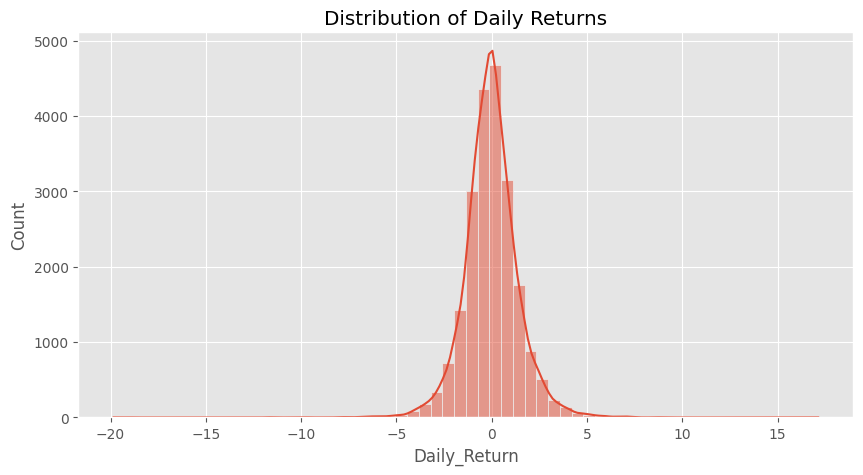

In [136]:
plt.figure(figsize=(10,5))

sns.histplot(
    master_df["Daily_Return"],
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

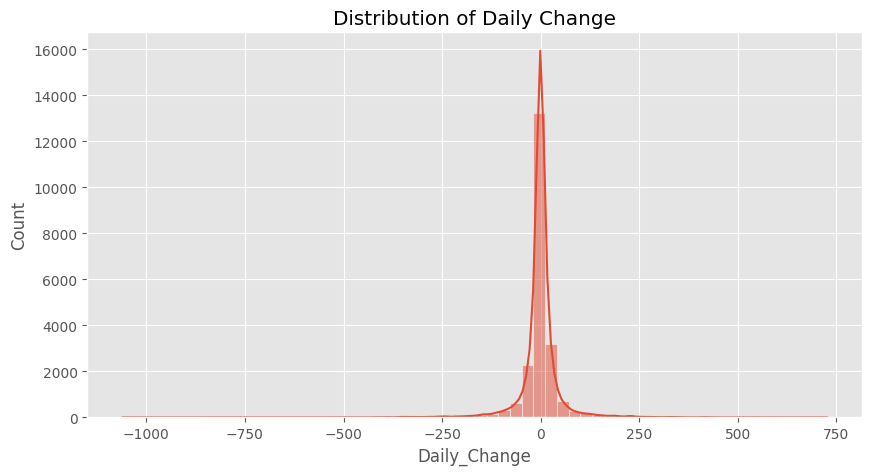

In [137]:
plt.figure(figsize=(10,5))

sns.histplot(
    master_df["Daily_Change"],
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Change")

plt.show()

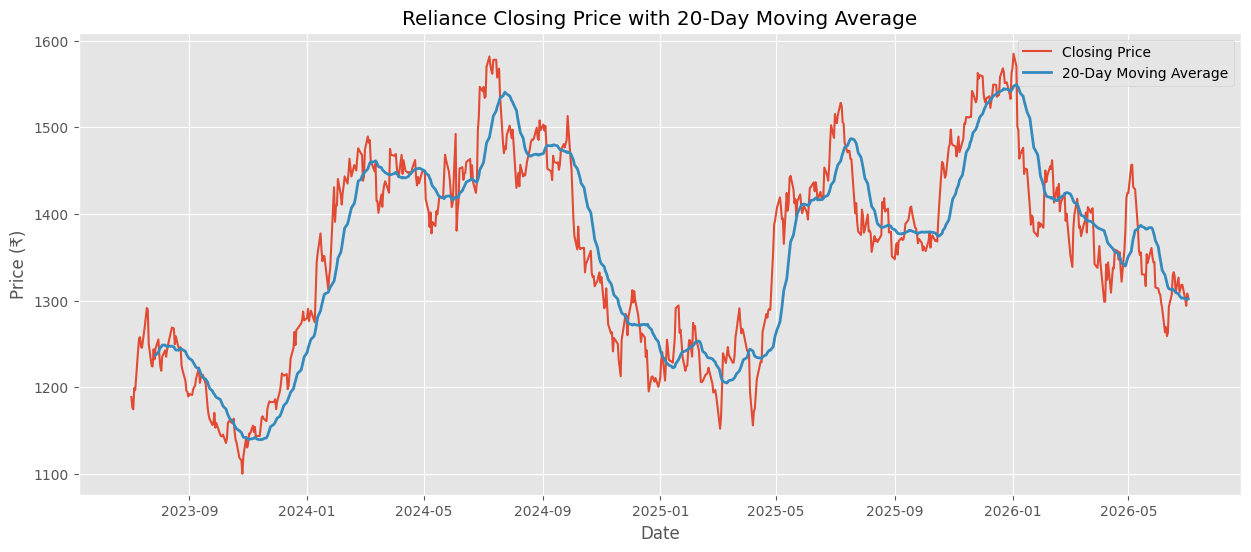

In [138]:
reliance = master_df[master_df["Stock"] == "RELIANCE"]

plt.figure(figsize=(15,6))

plt.plot(
    reliance["Date"],
    reliance["Close"],
    label="Closing Price",
    linewidth=1.5
)

plt.plot(
    reliance["Date"],
    reliance["MA20"],
    label="20-Day Moving Average",
    linewidth=2
)

plt.title("Reliance Closing Price with 20-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()

plt.show()

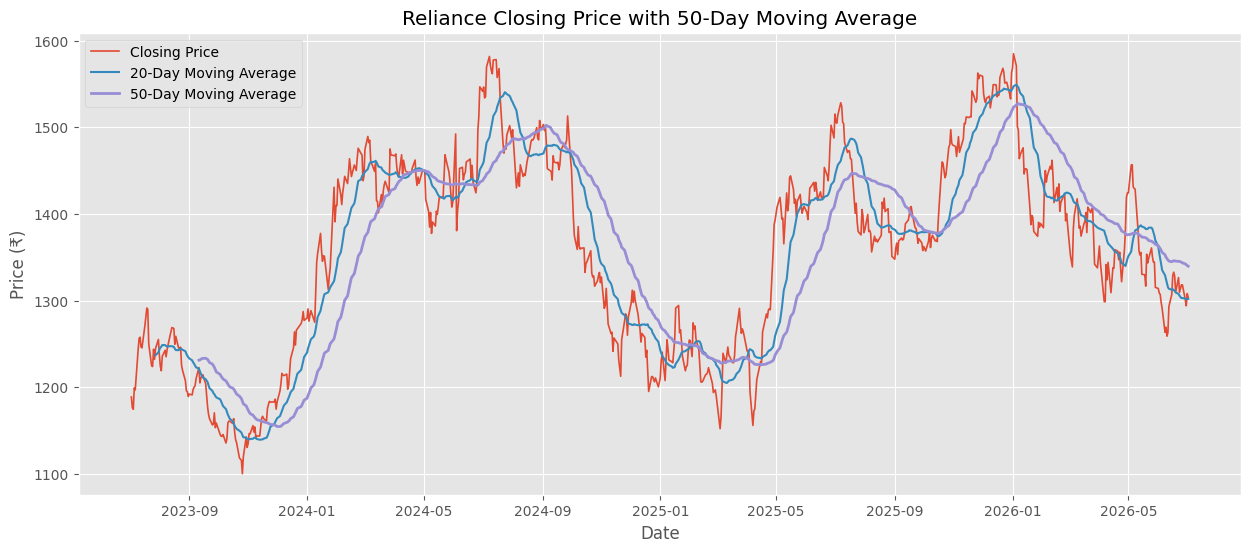

In [139]:
reliance = master_df[master_df["Stock"] == "RELIANCE"]

plt.figure(figsize=(15,6))

plt.plot(
    reliance["Date"],
    reliance["Close"],
    label="Closing Price",
    linewidth=1.2
)

plt.plot(
    reliance["Date"],
    reliance["MA20"],
    label="20-Day Moving Average",
    linewidth=1.5
)

plt.plot(
    reliance["Date"],
    reliance["MA50"],
    label="50-Day Moving Average",
    linewidth=2
)

plt.title("Reliance Closing Price with 50-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (₹)")
plt.legend()

plt.show()

**Observation(20-Day Moving Average)**

- The 20-Day Moving Average closely follows the closing price while smoothing short-term price fluctuations.
- It responds quickly to changes in the stock price, making short-term upward and downward trends easier to identify.
- The closing price frequently moves above and below the 20-Day Moving Average, reflecting normal day-to-day market fluctuations.

**Observation(50-Day Moving Average)**

- The 50-Day Moving Average is smoother than the 20-Day Moving Average because it averages a larger number of trading days.
- It reacts more slowly to sudden price changes and highlights the overall long-term trend of the stock.
- Throughout the analysis period, the 50-Day Moving Average provides a clearer representation of the general direction of Reliance's stock price by reducing short-term market noise.

## 4. Univariate Analysis

Univariate analysis examines the distribution and characteristics of individual variables independently. This helps identify patterns, measure variability, and detect potential outliers within the dataset.


In [140]:
# master_df["Close"].describe()

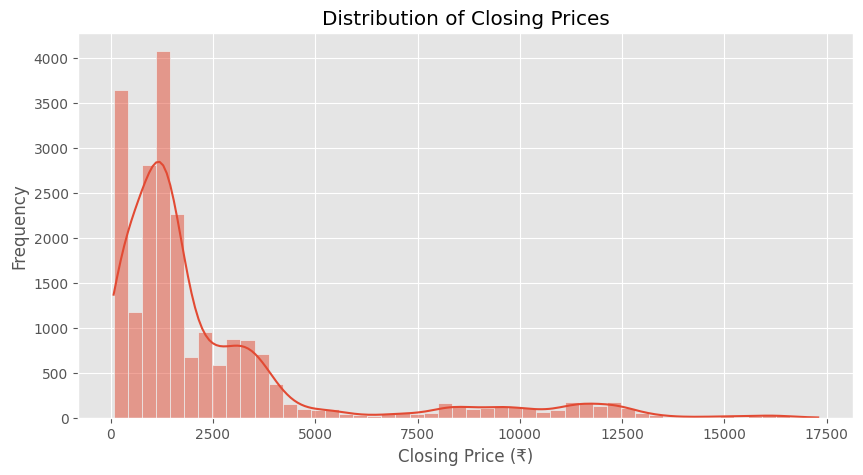

In [141]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=master_df,
    x="Close",
    bins=50,
    kde=True
)

plt.title("Distribution of Closing Prices")
plt.xlabel("Closing Price (₹)")
plt.ylabel("Frequency")

plt.show()

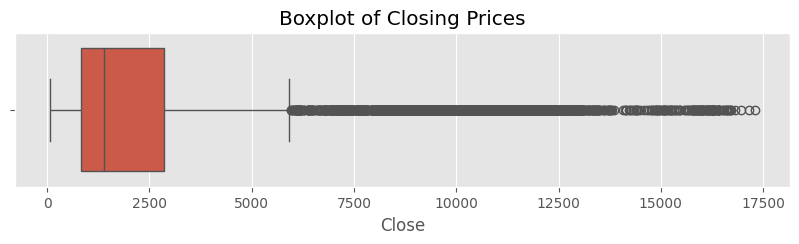

In [142]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=master_df["Close"]
)

plt.title("Boxplot of Closing Prices")

plt.show()

In [143]:
# master_df["Open"].describe()
# master_df["High"].describe()
# master_df["Low"].describe()

In [144]:
# master_df["Volume"].describe()

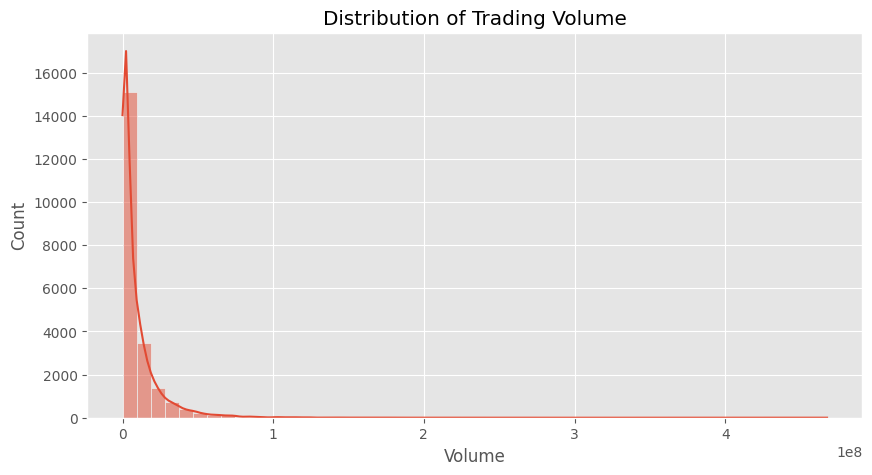

In [145]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=master_df,
    x="Volume",
    bins=50,
    kde=True
)

plt.title("Distribution of Trading Volume")

plt.show()

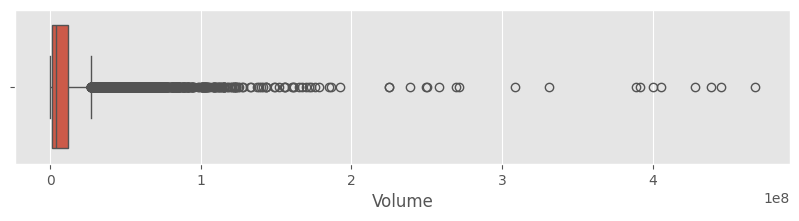

In [146]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=master_df["Volume"]
)

plt.show()

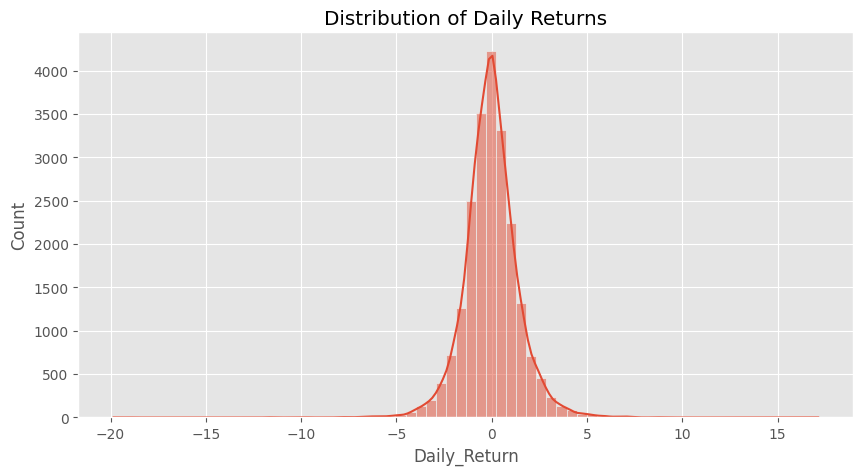

In [147]:
plt.figure(figsize=(10,5))

sns.histplot(
    master_df["Daily_Return"],
    bins=70,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.show()

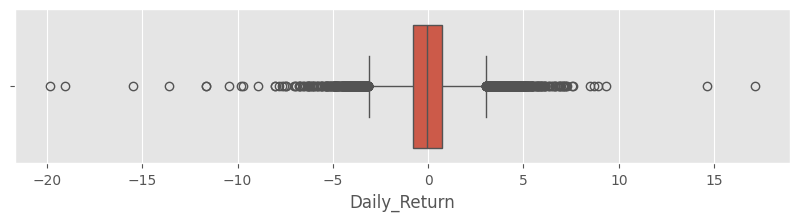

In [148]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=master_df["Daily_Return"]
)

plt.show()

In [149]:
master_df["Daily_Return"].describe()
master_df["Price_Range"].describe()

count    21707.000000
mean        51.433182
std         74.946179
min          0.000000
25%         12.861289
50%         25.870376
75%         53.240505
max       1169.821141
Name: Price_Range, dtype: float64

## 5. Bivariate Analysis

Bivariate analysis explores the relationship between two variables to identify trends, correlations, and patterns. This section helps understand how different financial variables interact with one another.


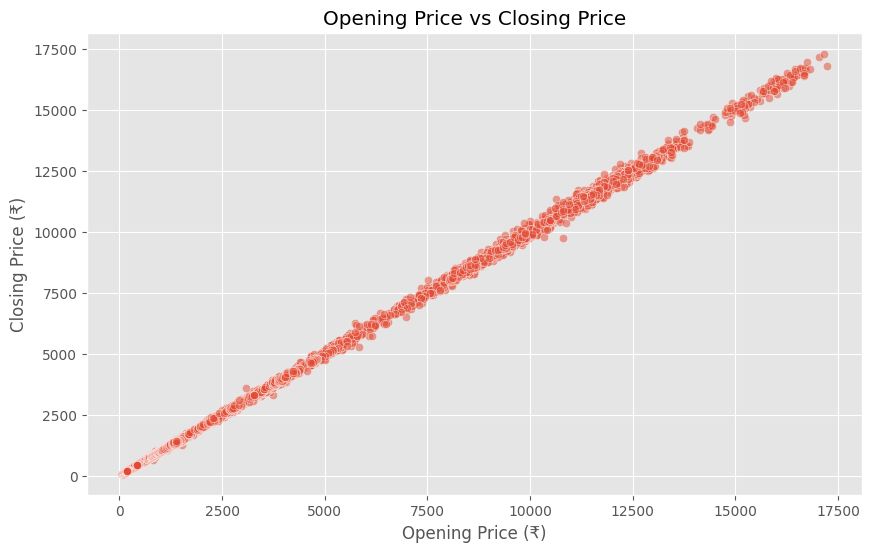

In [150]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=master_df,
    x="Open",
    y="Close",
    alpha=0.5
)

plt.title("Opening Price vs Closing Price")
plt.xlabel("Opening Price (₹)")
plt.ylabel("Closing Price (₹)")

plt.show()

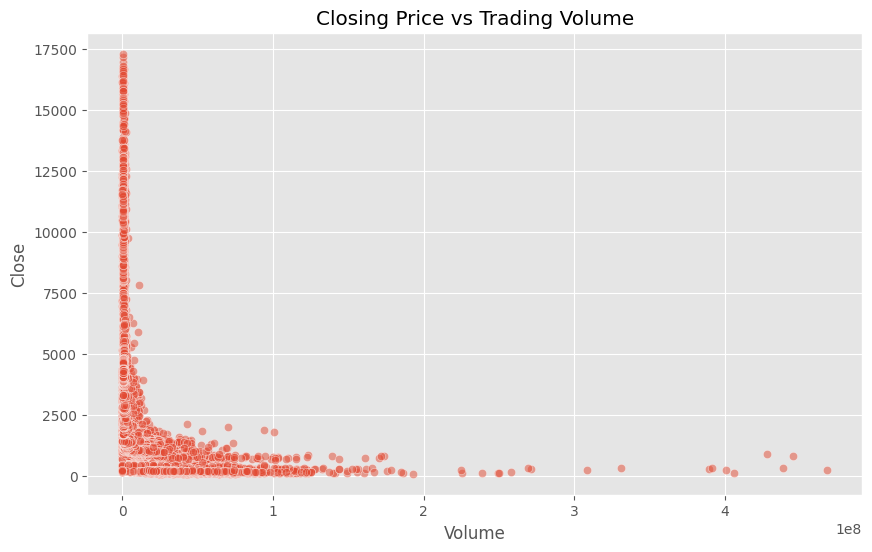

In [151]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=master_df,
    x="Volume",
    y="Close",
    alpha=0.5
)

plt.title("Closing Price vs Trading Volume")

plt.show()

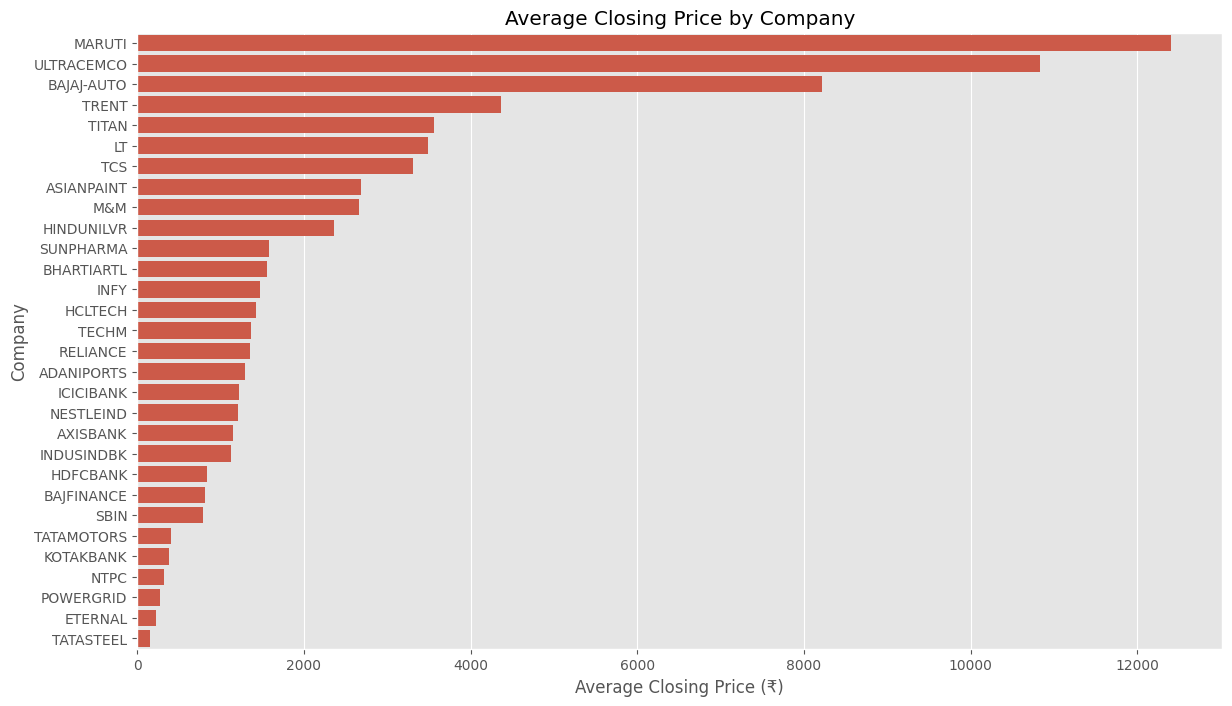

In [152]:
avg_close = (master_df.groupby("Stock")["Close"].mean().sort_values(ascending=False))

plt.figure(figsize=(14,8))

sns.barplot(
    x=avg_close.values,
    y=avg_close.index
)

plt.title("Average Closing Price by Company")
plt.xlabel("Average Closing Price (₹)")
plt.ylabel("Company")

plt.show()

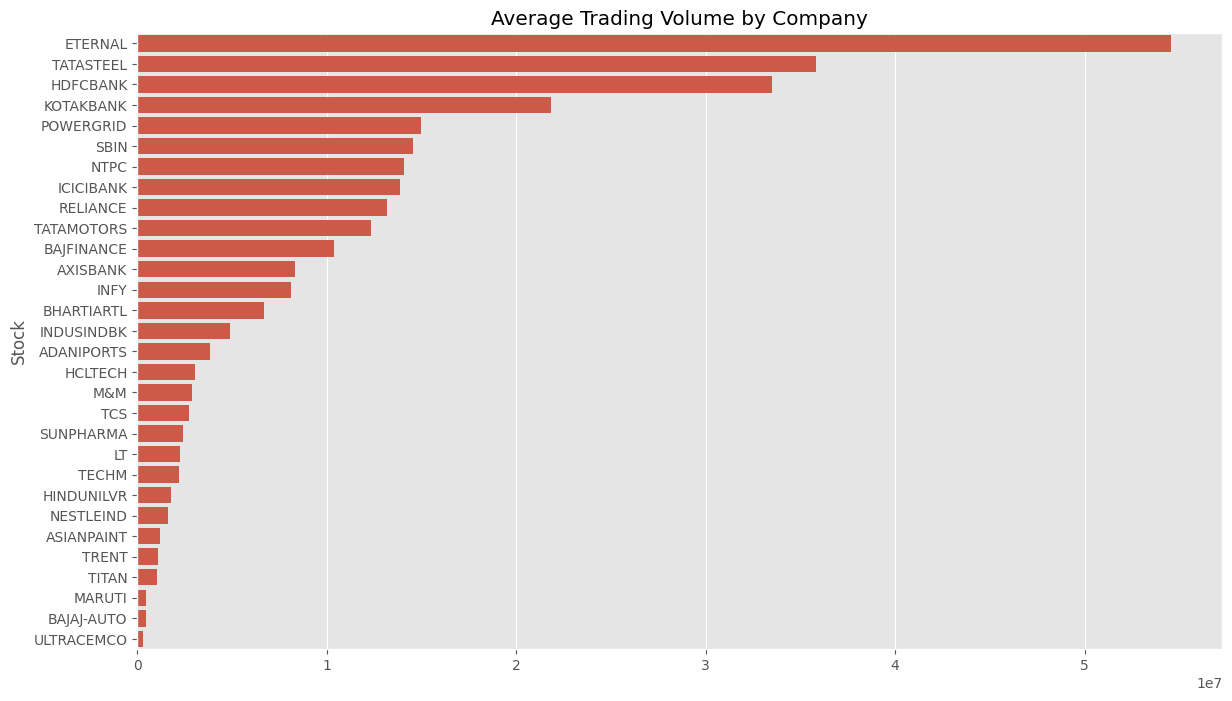

In [153]:
avg_volume = (master_df.groupby("Stock")["Volume"].mean().sort_values(ascending=False))

plt.figure(figsize=(14,8))

sns.barplot(
    x=avg_volume.values,
    y=avg_volume.index
)

plt.title("Average Trading Volume by Company")

plt.show()

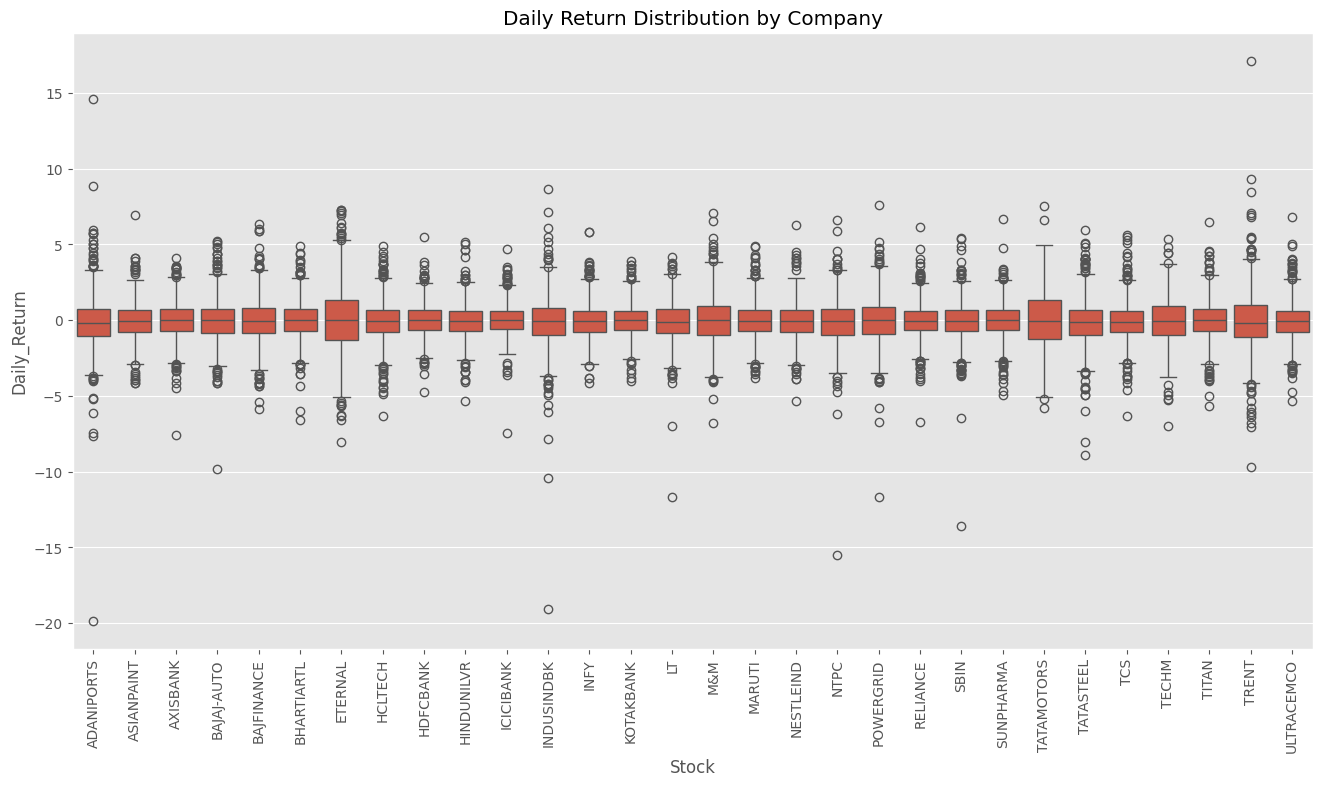

In [154]:
plt.figure(figsize=(16,8))

sns.boxplot(
    data=master_df,
    x="Stock",
    y="Daily_Return"
)

plt.xticks(rotation=90)

plt.title("Daily Return Distribution by Company")

plt.show()

## 6. Multivariate Analysis

Multivariate analysis examines the relationships among multiple variables simultaneously. In this project, a correlation analysis is performed to understand how the closing prices of different companies move relative to one another.

### 6.1 Correlation Heatmap of Closing Prices

A correlation heatmap is used to measure the strength of the relationship between the closing prices of different companies. Correlation values range from **-1 to +1**, where values closer to **+1** indicate that two stocks tend to move in a similar direction, values near **0** indicate little or no linear relationship, and values closer to **-1** indicate that the stocks tend to move in opposite directions.

In [155]:
close_prices = master_df.pivot(    #pivot() reshapes the dataframe from long format to wide format.
    index="Date",
    columns="Stock",
    values="Close"
)  #since corr() cannot compare them directly because there aren't separate numeric columns.

correlation = close_prices.corr() #correlation coefficient between Companies on basis of Closing Prices

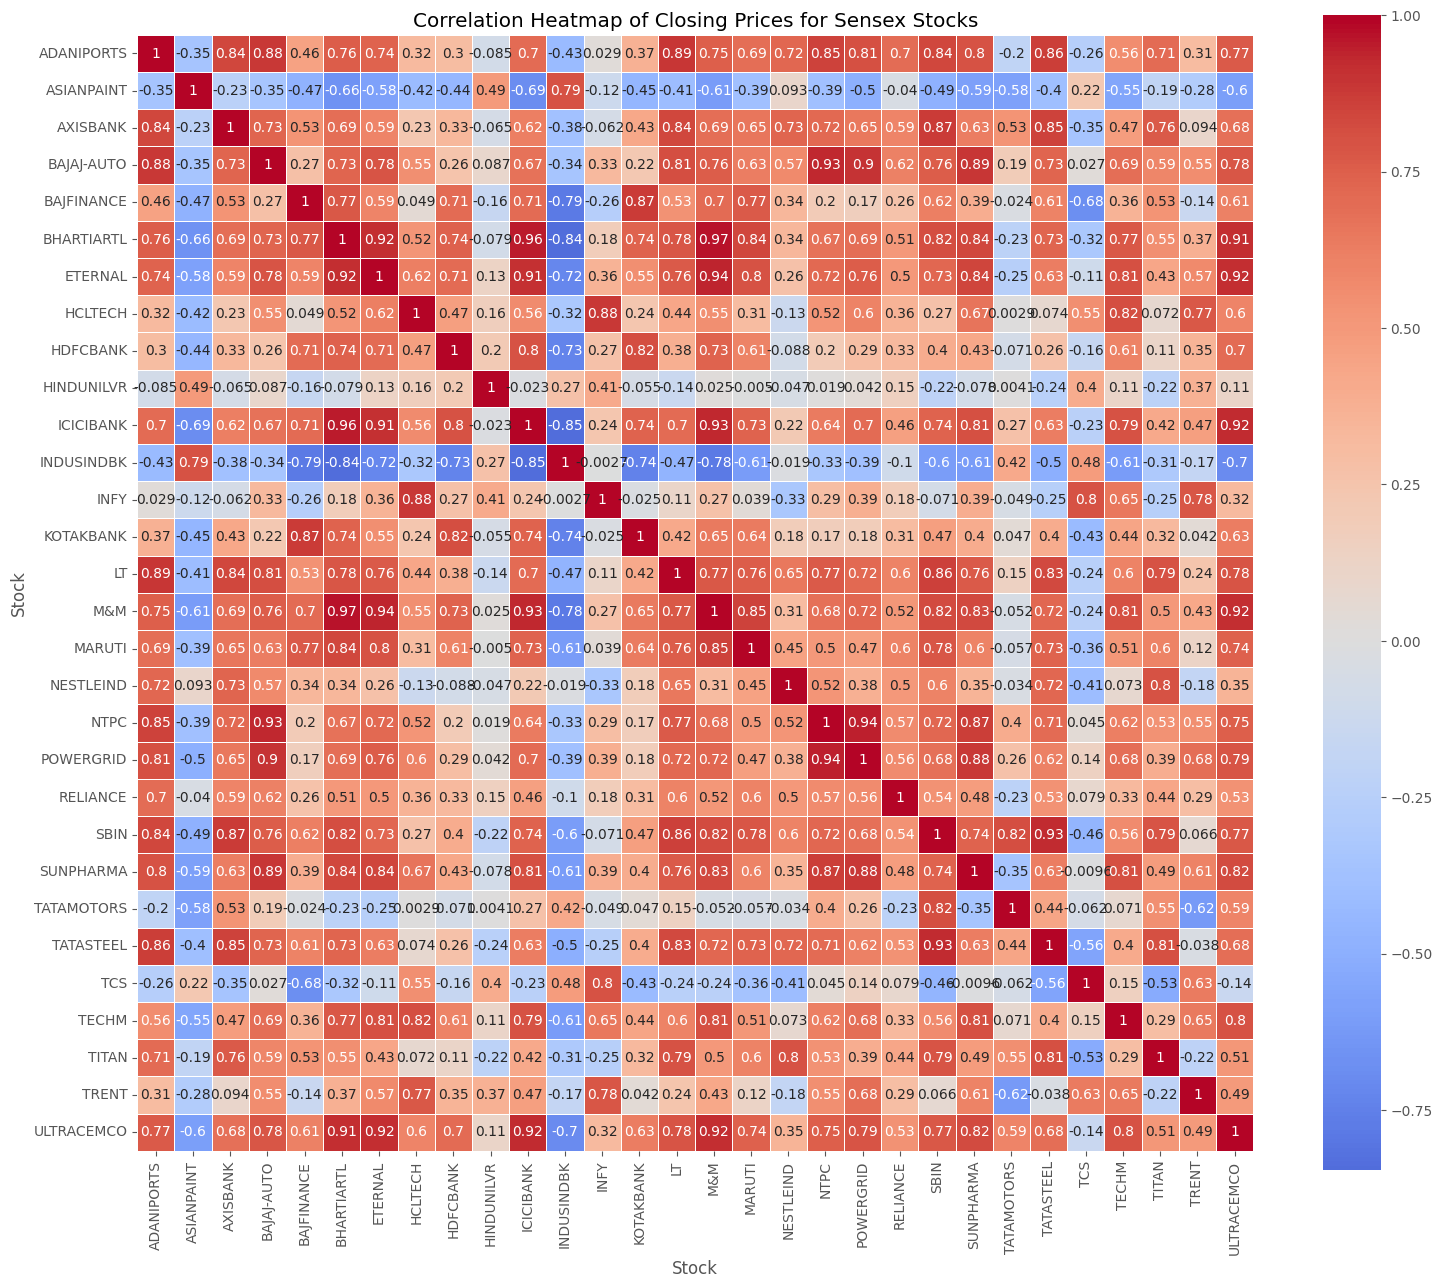

In [156]:
plt.figure(figsize=(18,15))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True, annot=True
)

plt.title("Correlation Heatmap of Closing Prices for Sensex Stocks")

plt.show()

**Observation**

- Most company pairs exhibit positive correlations, indicating that many stocks generally moved in similar directions during the analysis period.
- A few company pairs show weak or negative correlations, suggesting differences in their historical price movements.
- The diagonal values are equal to **1**, as each company's closing prices are perfectly correlated with themselves.
- The heatmap provides an overall view of the relationships between the closing prices of the selected Sensex companies.

## 7. Time Series Analysis

Time series analysis examines how stock prices and trading activity change over time. This section highlights historical trends and moving averages to better understand the long-term behavior of stock prices.


In [157]:
stock_df = master_df[master_df["Stock"] == "RELIANCE"].copy()

stock_df.sort_values("Date", inplace=True)

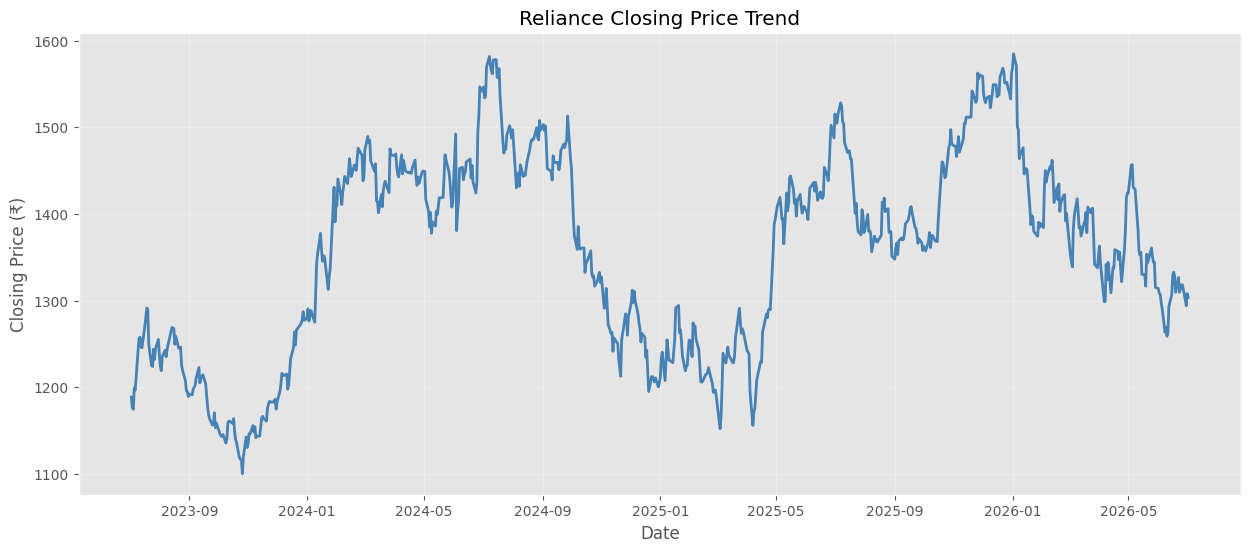

In [158]:
plt.figure(figsize=(15,6))

plt.plot(
    stock_df["Date"],
    stock_df["Close"],
    linewidth=2,
    color="steelblue"
)

plt.title("Reliance Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")

plt.grid(alpha=0.3)

plt.show()

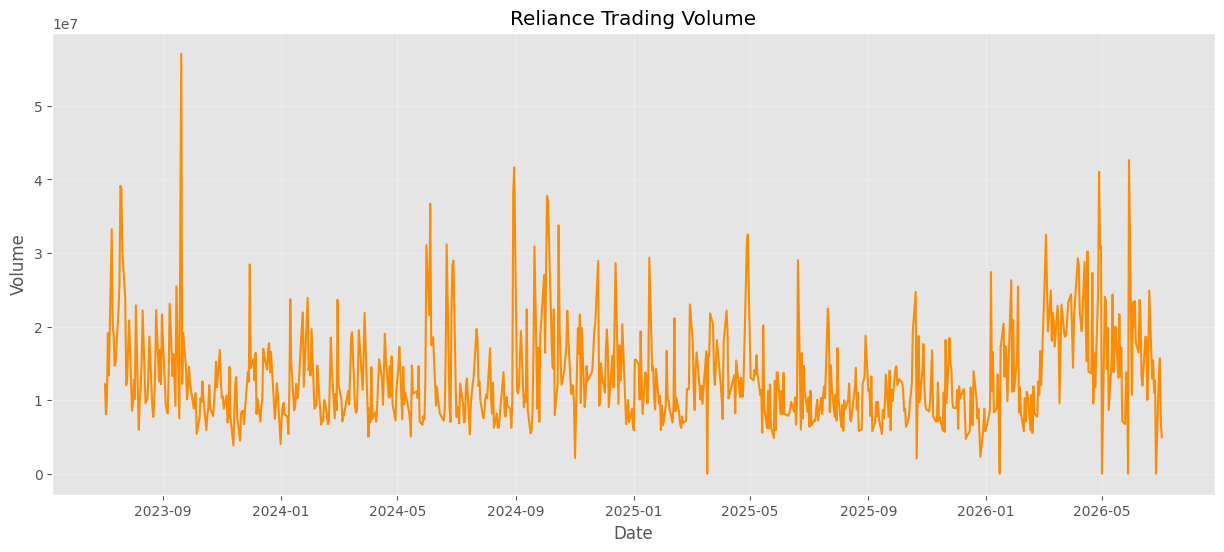

In [159]:
plt.figure(figsize=(15,6))

plt.plot(
    stock_df["Date"],
    stock_df["Volume"],
    color="darkorange"
)

plt.title("Reliance Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(alpha=0.3)

plt.show()

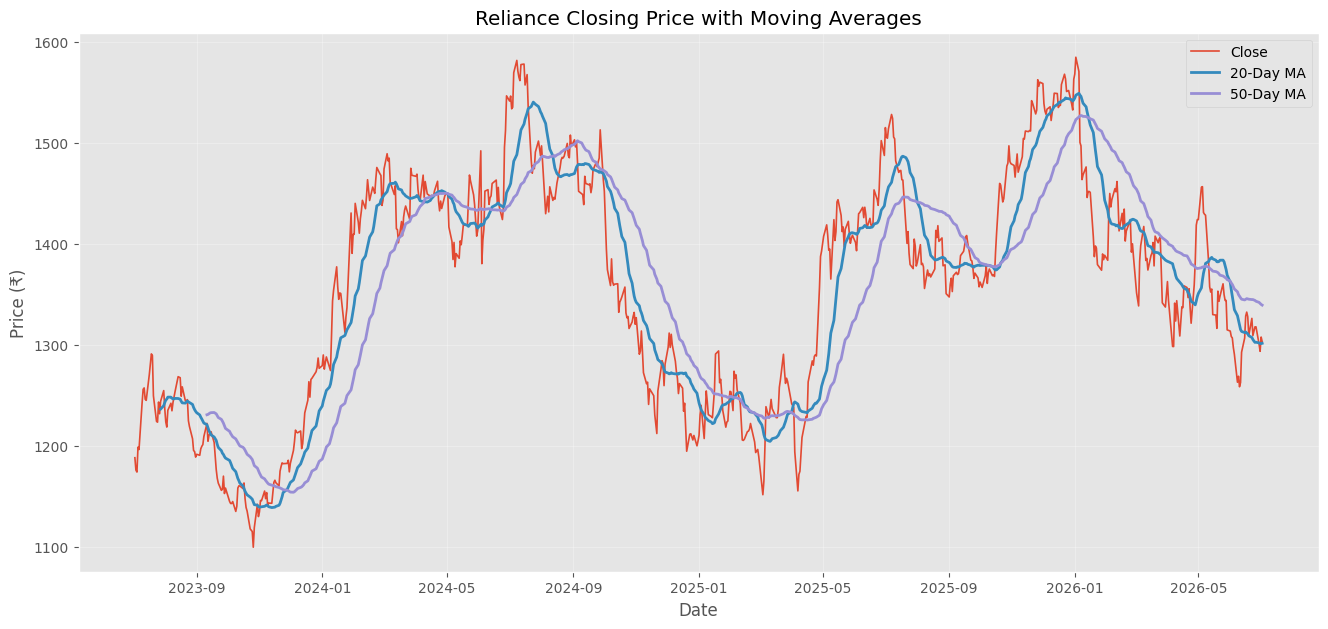

In [160]:
plt.figure(figsize=(16,7))

plt.plot(
    stock_df["Date"],
    stock_df["Close"],
    label="Close",
    linewidth=1.2
)

plt.plot(
    stock_df["Date"],
    stock_df["MA20"],
    label="20-Day MA",
    linewidth=2
)

plt.plot(
    stock_df["Date"],
    stock_df["MA50"],
    label="50-Day MA",
    linewidth=2
)

plt.title("Reliance Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (₹)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## 8. Performance Analysis

This section compares the historical performance of different companies using return and volatility metrics. It helps identify differences in stock performance and overall market behavior across the selected companies.


In [161]:
avg_return = (master_df.groupby("Stock")["Daily_Return"].mean().sort_values(ascending=False))

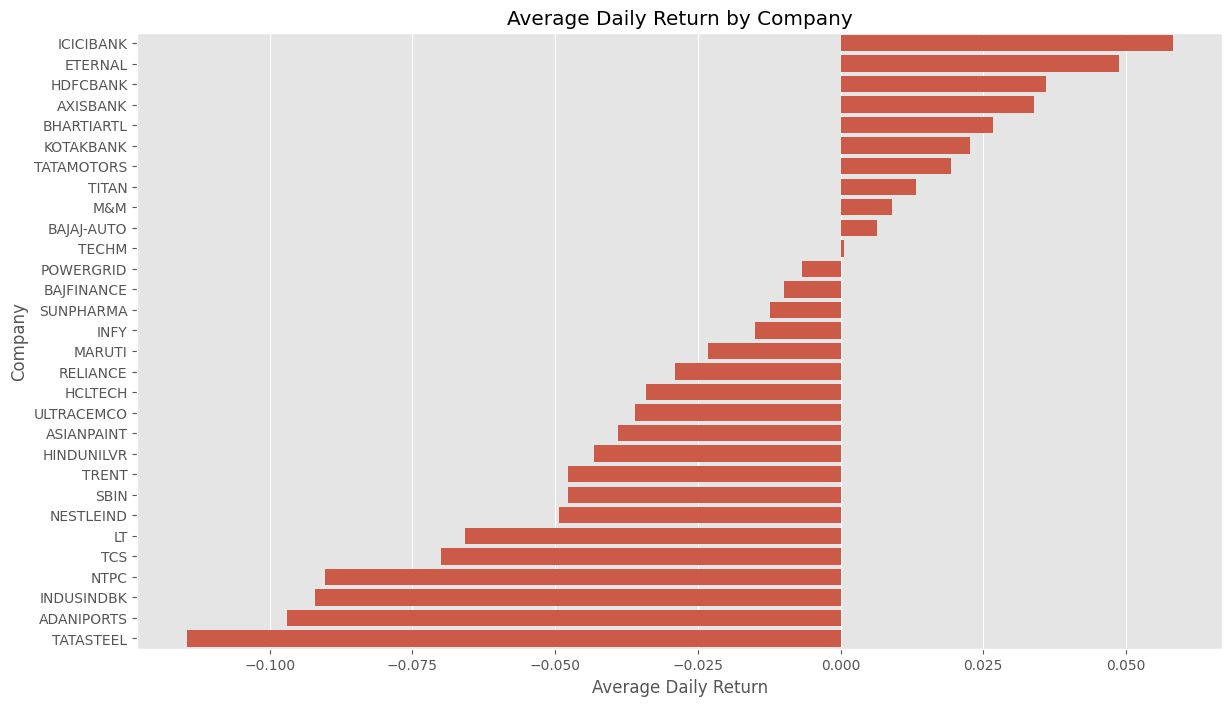

In [162]:
plt.figure(figsize=(14,8))

sns.barplot(
    x=avg_return.values,
    y=avg_return.index
)

plt.title("Average Daily Return by Company")
plt.xlabel("Average Daily Return")
plt.ylabel("Company")

plt.show()

In [163]:
performance = master_df.groupby("Stock").agg(
    First_Close=("Close","first"),
    Last_Close=("Close","last")
)

performance["Total_Return_%"] = ((performance["Last_Close"]-performance["First_Close"])/performance["First_Close"])*100

performance.sort_values(
    "Total_Return_%",
    ascending=False,
    inplace=True
)

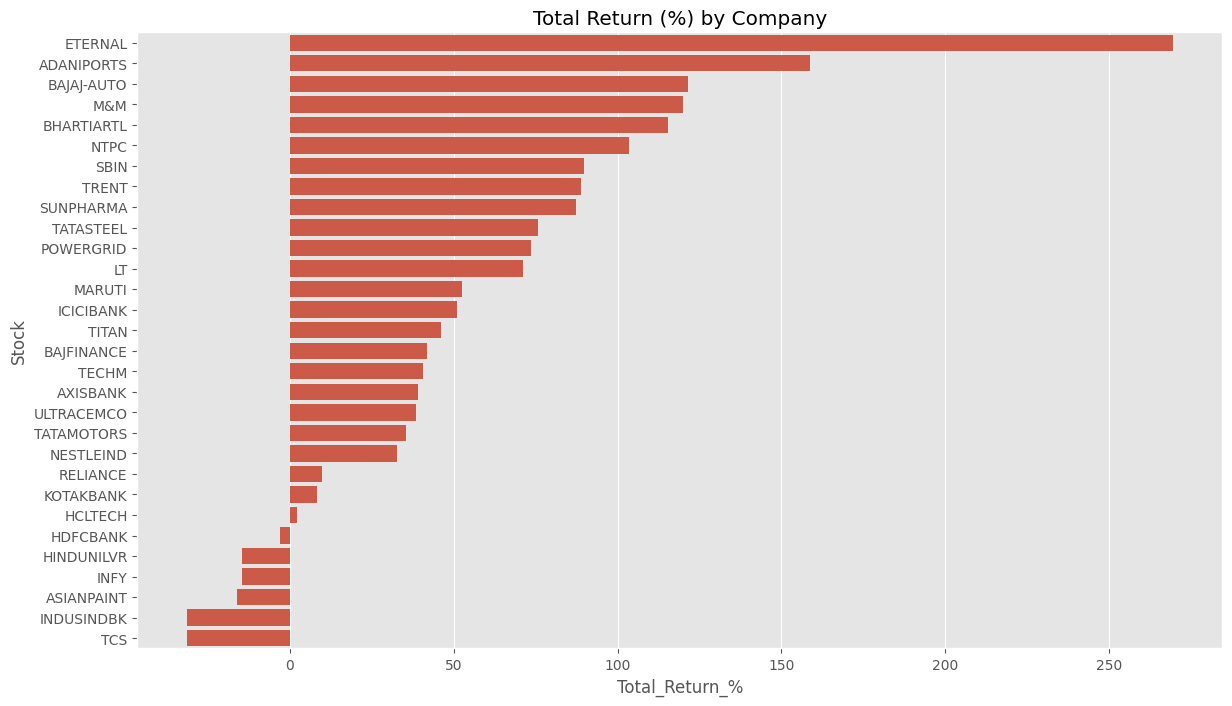

In [164]:
plt.figure(figsize=(14,8))

sns.barplot(
    x=performance["Total_Return_%"],
    y=performance.index
)

plt.title("Total Return (%) by Company")

plt.show()

In [165]:
volatility = (master_df.groupby("Stock")["Daily_Return"].std().sort_values(ascending=False)) #Standard Deviation of Return

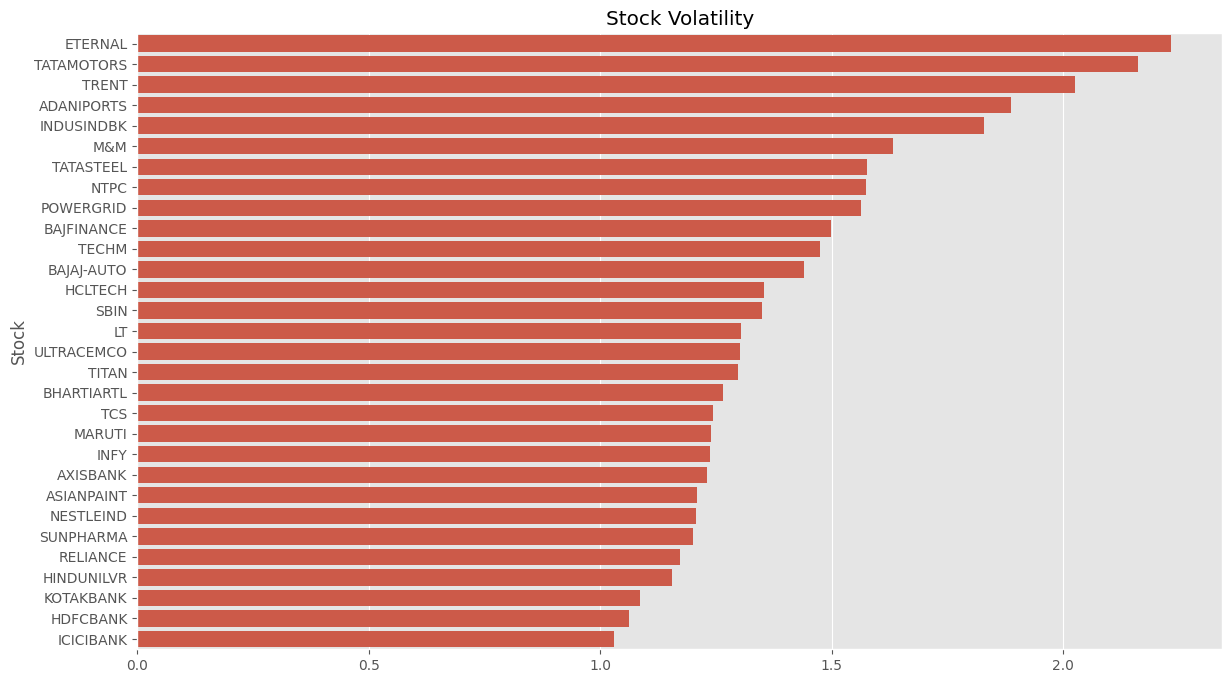

In [166]:
plt.figure(figsize=(14,8))

sns.barplot(
    x=volatility.values,
    y=volatility.index
)

plt.title("Stock Volatility")

plt.show()

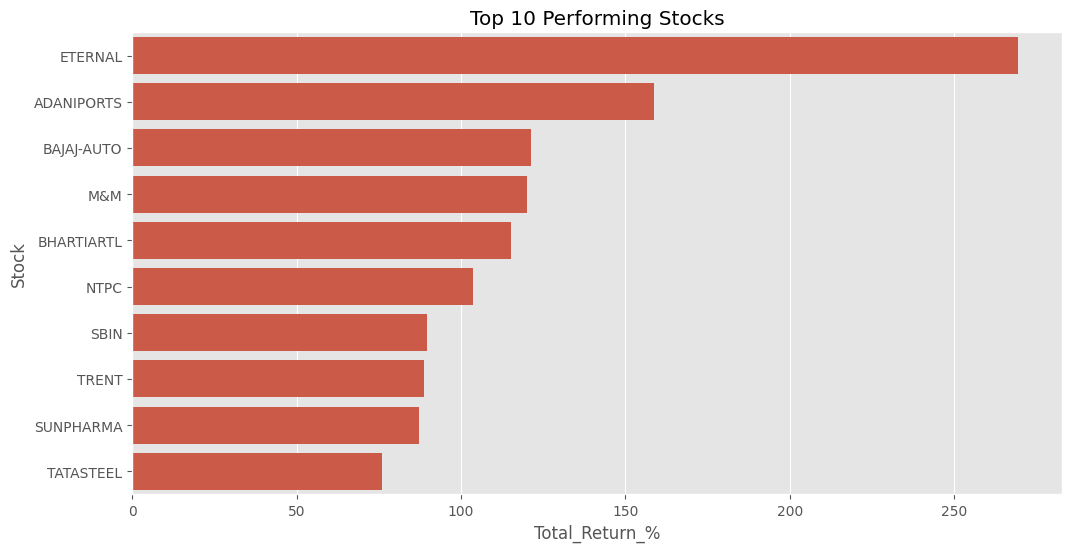

In [167]:
top10 = performance.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10["Total_Return_%"],
    y=top10.index
)

plt.title("Top 10 Performing Stocks")

plt.show()

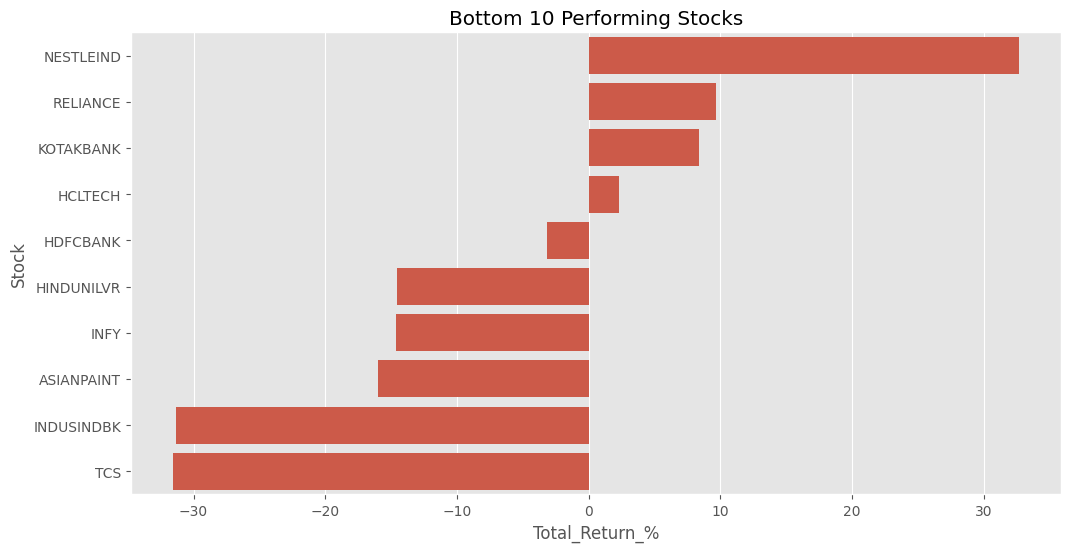

In [168]:
bottom10 = performance.tail(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=bottom10["Total_Return_%"],
    y=bottom10.index
)

plt.title("Bottom 10 Performing Stocks")

plt.show()

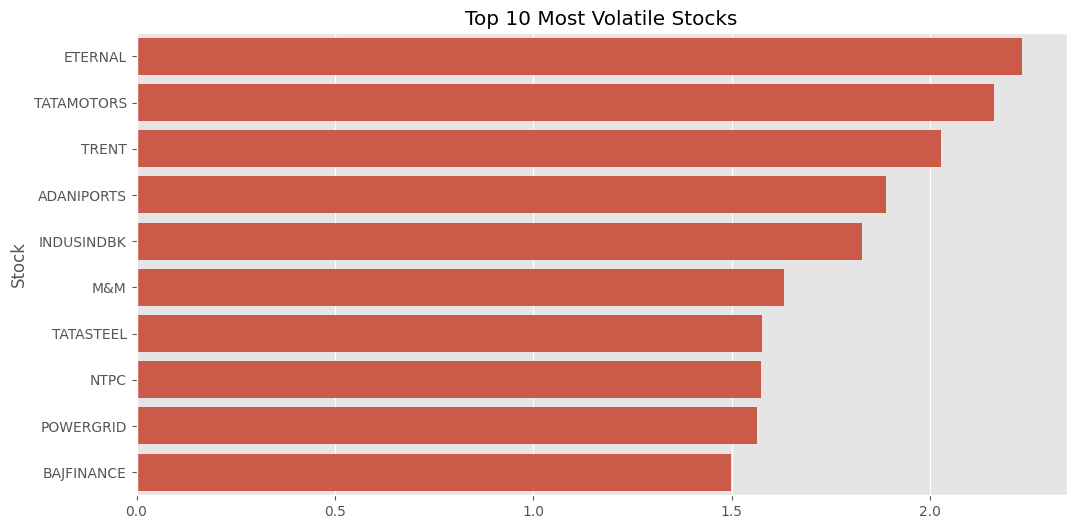

In [169]:
highest_risk = volatility.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=highest_risk.values,
    y=highest_risk.index
)

plt.title("Top 10 Most Volatile Stocks")

plt.show()

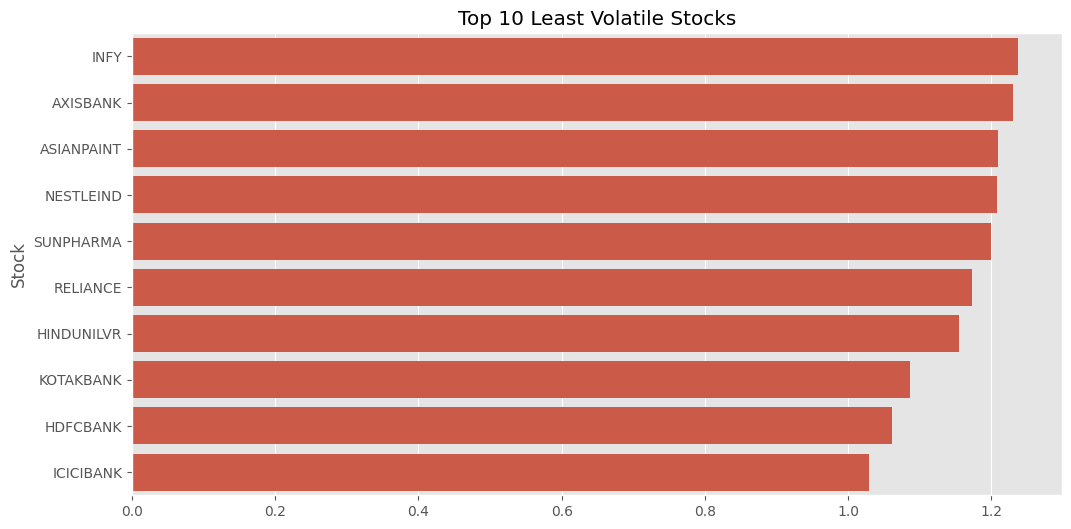

In [170]:
lowest_risk = volatility.tail(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=lowest_risk.values,
    y=lowest_risk.index
)

plt.title("Top 10 Least Volatile Stocks")

plt.show()

# Key Insights

The exploratory data analysis of the historical stock prices of the Top 30 companies listed in the S&P BSE Sensex Index revealed several important findings.

## Dataset Quality

* The dataset contained no missing values or duplicate records.
* All financial values satisfied the required data validation checks.
* Each company contained a consistent number of trading records.
* The dataset was clean and suitable for further analysis.

---

## Stock Price Behaviour

* Stock prices varied significantly across different companies.
* Price-related variables showed positively skewed distributions with a few high-value outliers.
* Most daily price changes remained relatively small, with occasional sharp movements.

---

## Trading Volume

* Trading volume varied considerably across companies.
* Several trading sessions recorded unusually high trading activity.
* Trading volume fluctuated over time, reflecting changes in market activity.

---

## Company Performance

* Average stock prices differed significantly across companies.
* Historical daily returns varied among companies, indicating differences in overall performance.
* Performance comparisons helped identify the highest and lowest performing companies during the analysis period.

---

## Correlation Analysis

* Several companies exhibited strong positive correlations in their closing prices.
* The correlation matrix highlighted similarities and differences in historical price movements across companies.

---

## Time Series Analysis

* Most companies displayed clear long-term trends in their stock prices.
* Moving averages effectively reduced short-term fluctuations and highlighted overall price trends.
* Historical trading volume showed noticeable changes throughout the analysis period.

---

## Overall Findings

* Historical stock performance varied across the Top 30 Sensex companies.
* Feature engineering improved the analytical value of the dataset.
* The insights obtained from this analysis provide a strong foundation for developing an interactive Streamlit dashboard for stock exploration and comparison.


# Conclusion

This project successfully performed an Exploratory Data Analysis (EDA) on the historical stock prices of the Top 30 companies listed in the S&P BSE Sensex Index.

The analysis involved understanding the dataset, assessing data quality, performing feature engineering, exploring stock price behavior, analyzing trading volume, comparing company performance, and studying historical trends through time-series analysis. These steps provided valuable insights into the historical performance and characteristics of the stock market data.

The insights obtained from this analysis establish a strong understanding of the dataset and demonstrate the practical application of data analysis techniques on real-world financial data. The engineered features and analytical findings developed throughout this notebook will serve as the foundation for building an interactive Streamlit dashboard.

The Streamlit dashboard will allow users to explore historical stock trends, compare company performance, visualize important financial metrics, and interactively analyze the dataset through an intuitive interface.

Overall, this project demonstrates a complete end-to-end data analysis workflow, from data preparation and exploration to insight generation and visualization. It also provides a solid foundation for future enhancements such as additional financial indicators, real-time data integration, and predictive analytics.

# Future Scope

This project can be further enhanced in several ways to provide additional insights and improve user experience:

* Develop a fully interactive Streamlit dashboard for stock exploration and comparison.
* Add interactive filters for company selection, date range, and key financial metrics.
* Integrate real-time stock market data using financial APIs.
* Include additional technical indicators such as RSI, MACD, and Bollinger Bands.
* Expand the analysis to include other stock market indices and sectors.
* Develop machine learning models to forecast future stock prices.